## Diagnostics: Argument Error Composition

This section reads `evaluation_mismatch_diagnostics.csv` from the same
top-level strategy directories. The denominator is all `argument_mismatch` rows
for the same `domain + model + strategy`.

Two high-signal diagnostic families are shown:
- split head/modifier words: `unnecessary_head_or_modifier_split`
- preposition arguments: `preposition_object` or `preposition_argument`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    METHOD_ORDER,
    MODEL_LABELS,
    MODEL_ORDER,
    read_arg_mismatch_diagnostics,
)
from utils.helpers import find_project_root


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

DIAGNOSTIC_ISSUES = {
    "Split head/modifier": ["unnecessary_head_or_modifier_split"],
    "Preposition arg": ["preposition_object", "preposition_argument"],
}

diagnostics_df = read_arg_mismatch_diagnostics(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)


In [2]:
rows = []
for (domain, method, model), group in diagnostics_df.groupby(
    ["domain", "method", "model"], observed=True
):
    arg_errors = len(group)
    issue_text = group["issue_text"].fillna("")

    for issue, needles in DIAGNOSTIC_ISSUES.items():
        count = issue_text.str.contains("|".join(needles), regex=True, na=False).sum()
        rows.append(
            {
                "domain": domain,
                "method": method,
                "model": model,
                "issue": issue,
                "count": int(count),
                "arg_errors": int(arg_errors),
                "share": count / arg_errors if arg_errors else np.nan,
            }
        )

diag_issue_share_df = pd.DataFrame(rows).sort_values(
    ["issue", "domain", "model", "method"]
)
display(diag_issue_share_df.head(5))


,domain,method,model,issue,count,arg_errors,share
31,cooking,nl2p_1,gemma3-12b,Preposition arg,413,1066,0.387430
41,cooking,nl2p_1_ablation,gemma3-12b,Preposition arg,351,1013,0.346496
51,cooking,nl2p_1_coref,gemma3-12b,Preposition arg,436,1069,0.407858
33,cooking,nl2p_1,gemma3-27b,Preposition arg,299,849,0.352179
43,cooking,nl2p_1_ablation,gemma3-27b,Preposition arg,179,807,0.221809


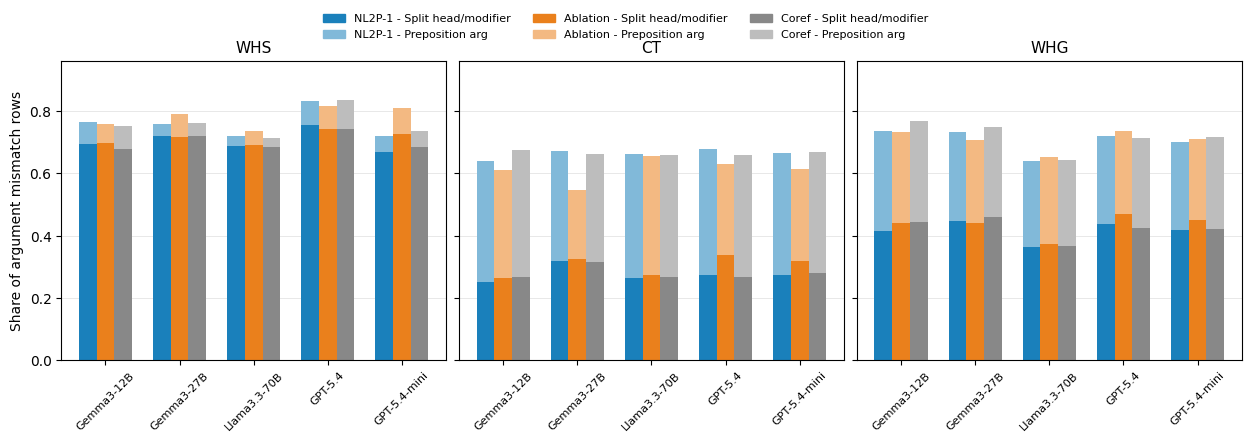

In [3]:
method_colors = {
    "nl2p_1": "#1a80bb",
    "nl2p_1_ablation": "#ea801c",
    "nl2p_1_coref": "#888888",
}
method_offsets = {
    "nl2p_1": -0.24,
    "nl2p_1_ablation": 0.0,
    "nl2p_1_coref": 0.24,
}
issues = list(DIAGNOSTIC_ISSUES)
models = [model for model in MODEL_ORDER if model in set(diag_issue_share_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]


def lighten(hex_color, factor=0.45):
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f"#{r:02x}{g:02x}{b:02x}"

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(DOMAIN_ORDER),
    figsize=(12.4, 4.0),
    sharey=True,
    constrained_layout=True,
)

x = np.arange(len(models))
width = 0.24
stack_max = diag_issue_share_df.groupby(["domain", "method", "model"], observed=True)["share"].sum().max()
y_max = max(0.25, stack_max * 1.15 if pd.notna(stack_max) else 0.25)

for col_idx, domain in enumerate(DOMAIN_ORDER):
    ax = axes[col_idx]
    panel = diag_issue_share_df[diag_issue_share_df["domain"].astype(str) == domain]

    for method_key in METHOD_ORDER:
        bottom = np.zeros(len(models))
        for issue_idx, issue in enumerate(issues):
            values = []
            for model in models:
                row = panel[
                    (panel["method"].astype(str) == method_key)
                    & (panel["model"].astype(str) == model)
                    & (panel["issue"] == issue)
                ]
                values.append(0.0 if row.empty else float(row.iloc[0]["share"]))

            values = np.array(values)
            base_color = method_colors[method_key]
            bar_color = base_color if issue_idx == 0 else lighten(base_color)
            ax.bar(
                x + method_offsets[method_key],
                values,
                bottom=bottom,
                width=width,
                color=bar_color,
                edgecolor="none",
            )
            bottom += values

    ax.set_title(DOMAIN_LABELS[domain], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=45, fontsize=8)
    ax.set_ylim(0.0, y_max)
    ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    if col_idx == 0:
        ax.set_ylabel("Share of argument mismatch rows")

handles = []
for method_key in METHOD_ORDER:
    for issue_idx, issue in enumerate(issues):
        handles.append(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=method_colors[method_key] if issue_idx == 0 else lighten(method_colors[method_key]),
                label=f"{METHOD_LABELS[method_key]} - {issue}",
            )
        )

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(METHOD_ORDER),
    frameon=False,
    fontsize=8,
)
plt.show()


In [6]:
table_source = diag_issue_share_df.assign(
    domain=diag_issue_share_df["domain"].astype(str).map(DOMAIN_LABELS),
    method=diag_issue_share_df["method"].astype(str).map(METHOD_LABELS),
    model_label=diag_issue_share_df["model"].astype(str).map(MODEL_LABELS).fillna(diag_issue_share_df["model"].astype(str)),
)
table_source["domain"] = pd.Categorical(
    table_source["domain"], [DOMAIN_LABELS[key] for key in DOMAIN_ORDER], ordered=True
)
table_source["method"] = pd.Categorical(
    table_source["method"], [METHOD_LABELS[key] for key in METHOD_ORDER], ordered=True
)

diag_issue_table = table_source.pivot_table(
    index=["issue", "method", "model_label"],
    columns="domain",
    values="share",
    aggfunc="first",
    observed=False,
)
display((diag_issue_table * 100).round(2))


domain                                       WHS     CT    WHG
issue               method   model_label                      
Preposition arg     NL2P-1   GPT-5.4        7.79  40.31  28.25
                             GPT-5.4-mini   5.25  39.05  27.97
                             Gemma3-12B     7.00  38.74  32.06
                             Gemma3-27B     4.01  35.22  28.29
                             Llama3.3-70B   3.18  39.80  27.61
                    Ablation GPT-5.4        7.42  29.27  26.56
                             GPT-5.4-mini   8.14  29.32  25.80
                             Gemma3-12B     6.03  34.65  29.11
                             Gemma3-27B     7.55  22.18  26.64
                             Llama3.3-70B   4.40  38.16  27.88
                    Coref    GPT-5.4        9.22  39.24  28.71
                             GPT-5.4-mini   5.16  38.89  29.38
                             Gemma3-12B     7.25  40.79  32.13
                             Gemma3-27B     4.19  34.49  28.62
                             Llama3.3-70B   3.02  39.30  27.56
Split head/modifier NL2P-1   GPT-5.4       75.39  27.55  43.75
                             GPT-5.4-mini  66.76  27.40  41.95
                             Gemma3-12B    69.54  25.23  41.53
                             Gemma3-27B    71.91  31.92  44.86
                             Llama3.3-70B  68.84  26.53  36.32
                    Ablation GPT-5.4       74.18  33.73  46.93
                             GPT-5.4-mini  72.77  32.00  45.09
                             Gemma3-12B    69.71  26.36  44.15
                             Gemma3-27B    71.59  32.47  44.22
                             Llama3.3-70B  69.18  27.47  37.49
                    Coref    GPT-5.4       74.38  26.67  42.58
                             GPT-5.4-mini  68.44  27.92  42.24
                             Gemma3-12B    67.95  26.66  44.54
                             Gemma3-27B    71.86  31.62  46.12
                             Llama3.3-70B  68.41  26.72  36.57